# 03 — Baseline-Modell + XGBoost

**Ziel:** Aus den Features ein Modell bauen, das die Heimsieg-Wahrscheinlichkeit vorhersagt.

**Vorgehen:**
1. Trivial-Baseline: "immer Heimsieg vorhersagen" — was ist die Hitrate?
2. Logistische Regression — interpretierbares ML-Baseline-Modell
3. XGBoost — leistungsstaerker, lernt Wechselwirkungen automatisch
4. Evaluation: Accuracy, Log-Loss, Brier-Score, Feature Importance, Kalibrierung

**Goldene Regel — Zeitbasierter Split!**
Wir teilen nicht zufaellig. Wir trainieren auf alten Saisons und testen auf neueren — sonst leakt Information aus der Zukunft in die Vergangenheit. Im naechsten Notebook machen wir richtiges Walk-Forward-Backtesting.

## 1. Setup & Daten laden

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, log_loss, brier_score_loss,
    roc_auc_score, confusion_matrix, classification_report,
)
from sklearn.calibration import calibration_curve
import xgboost as xgb

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_parquet(Path('..') / 'data' / 'processed' / 'games_with_features.parquet')
df = df.sort_values('gameDate').reset_index(drop=True)
print(f'Spiele: {len(df):,}')
print(f'Zeitraum: {df.gameDate.min().date()} - {df.gameDate.max().date()}')

Spiele: 71,239
Zeitraum: 1946-11-26 - 2026-04-26


## 2. Feature-Spalten auswaehlen

Wir nehmen nur die generierten Features — keine direkten Score-Spalten oder Team-IDs (der Modell soll lernen, Sieg basierend auf Form/ELO vorherzusagen, nicht *welches Team* spielt).

In [2]:
feature_cols = [
    # ELO
    'home_elo_pre', 'away_elo_pre', 'elo_diff',
    # Head-to-Head
    'h2h_home_winrate_last5',
    # Form (Win-Rate)
    'home_win_rate_last_5', 'home_win_rate_last_10', 'home_win_rate_last_20',
    'away_win_rate_last_5', 'away_win_rate_last_10', 'away_win_rate_last_20',
    'win_rate_diff_5', 'win_rate_diff_10', 'win_rate_diff_20',
    # Form (Margin)
    'home_avg_margin_last_5', 'home_avg_margin_last_10', 'home_avg_margin_last_20',
    'away_avg_margin_last_5', 'away_avg_margin_last_10', 'away_avg_margin_last_20',
    'margin_diff_5', 'margin_diff_10', 'margin_diff_20',
    # Pause
    'home_days_since_last_game', 'away_days_since_last_game',
    'home_is_back_to_back', 'away_is_back_to_back', 'rest_diff',
]
TARGET = 'home_win'

print(f'Anzahl Features: {len(feature_cols)}')

Anzahl Features: 27


## 3. Daten saeubern

Die ersten paar Spiele jeder Saison haben NaN bei Rolling-Features. Wir lassen die ersten 10 Spiele pro Team und Saison weg, damit alle Features sinnvoll befuellt sind.

In [3]:
before = len(df)
df_model = df.dropna(subset=feature_cols).copy()
print(f'Vorher: {before:,}  |  Nachher: {len(df_model):,}  |  Entfernt: {before - len(df_model):,}')

Vorher: 71,239  |  Nachher: 70,265  |  Entfernt: 974


## 4. Zeitbasierter Train/Test-Split

**Train:** alle Saisons bis 2018  
**Test:** Saison 2019 und neuer

(Im naechsten Notebook walken wir mit einem rollierenden Fenster durch die Geschichte — das hier ist nur ein erster Sanity-Check.)

In [4]:
SPLIT_SEASON = 2019

train = df_model[df_model.season < SPLIT_SEASON]
test = df_model[df_model.season >= SPLIT_SEASON]

X_train, y_train = train[feature_cols], train[TARGET]
X_test, y_test = test[feature_cols], test[TARGET]

print(f'Train: {len(X_train):,}  ({train.season.min()} - {train.season.max()})')
print(f'Test:  {len(X_test):,}  ({test.season.min()} - {test.season.max()})')
print(f'\nHome-Win-Rate im Test: {y_test.mean():.1%}')

Train: 61,623  (1946 - 2018)
Test:  8,642  (2019 - 2025)

Home-Win-Rate im Test: 55.2%


## 5. Trivial-Baseline

**Wenn man immer "Heimsieg" tippt** — wie gut waere man? Das ist die unterste Latte, die jedes Modell schlagen muss.

In [5]:
trivial_pred = np.ones(len(y_test))                           # immer 1 (Heimsieg)
trivial_proba = np.full(len(y_test), y_train.mean())          # konstante Wahrscheinlichkeit = Trainingsanteil

results = {}
results['Trivial (immer Heim)'] = {
    'accuracy': accuracy_score(y_test, trivial_pred),
    'log_loss': log_loss(y_test, trivial_proba),
    'brier':    brier_score_loss(y_test, trivial_proba),
    'auc':      0.5,
}
results['Trivial (immer Heim)']

{'accuracy': 0.5523027077065494,
 'log_loss': 0.6991497265294142,
 'brier': 0.2527604951002067,
 'auc': 0.5}

## 6. Logistische Regression (interpretierbares Baseline-Modell)

Logistische Regression ist die einfachste sinnvolle Methode fuer Klassifikation. Bonus: Die Koeffizienten sagen direkt, *welches Feature wie stark* in Richtung Heimsieg/Auswaertssieg zieht.

Wir scalen die Features (StandardScaler), damit die Koeffizienten vergleichbar sind.

In [6]:
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
])
logreg.fit(X_train, y_train)

lr_proba = logreg.predict_proba(X_test)[:, 1]
lr_pred = (lr_proba >= 0.5).astype(int)

results['Logistische Regression'] = {
    'accuracy': accuracy_score(y_test, lr_pred),
    'log_loss': log_loss(y_test, lr_proba),
    'brier':    brier_score_loss(y_test, lr_proba),
    'auc':      roc_auc_score(y_test, lr_proba),
}
results['Logistische Regression']

{'accuracy': 0.6429067345521869,
 'log_loss': 0.6399453418621932,
 'brier': 0.22304838994506446,
 'auc': 0.6992110734018684}

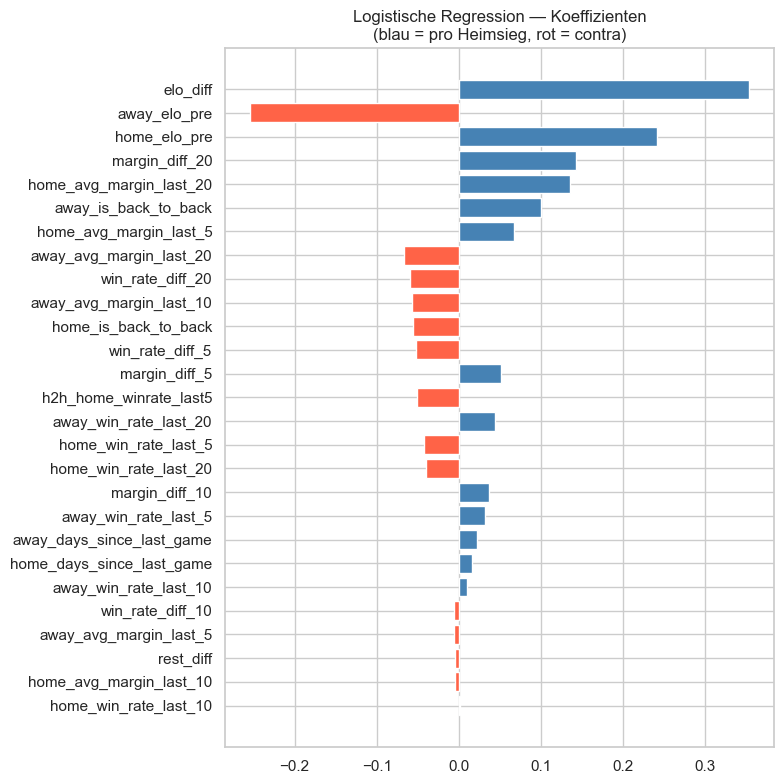

In [7]:
# Welche Features hat das lineare Modell als wichtig erkannt?
coefs = pd.DataFrame({
    'feature': feature_cols,
    'coef': logreg.named_steps['clf'].coef_[0],
}).assign(abs_coef=lambda d: d.coef.abs()).sort_values('abs_coef', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['steelblue' if c > 0 else 'tomato' for c in coefs.coef]
ax.barh(coefs.feature, coefs.coef, color=colors)
ax.set_title('Logistische Regression — Koeffizienten\n(blau = pro Heimsieg, rot = contra)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. XGBoost

Gradient-Boosted Trees — der Standard fuer tabellarische Daten. Lernt automatisch Wechselwirkungen (z.B. "Back-to-Back schadet nur Teams mit niedrigem ELO").

In [8]:
xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_proba >= 0.5).astype(int)

results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, xgb_pred),
    'log_loss': log_loss(y_test, xgb_proba),
    'brier':    brier_score_loss(y_test, xgb_proba),
    'auc':      roc_auc_score(y_test, xgb_proba),
}
results['XGBoost']

{'accuracy': 0.6416338810460541,
 'log_loss': 0.641159582914238,
 'brier': 0.223862886428833,
 'auc': 0.697751286542934}

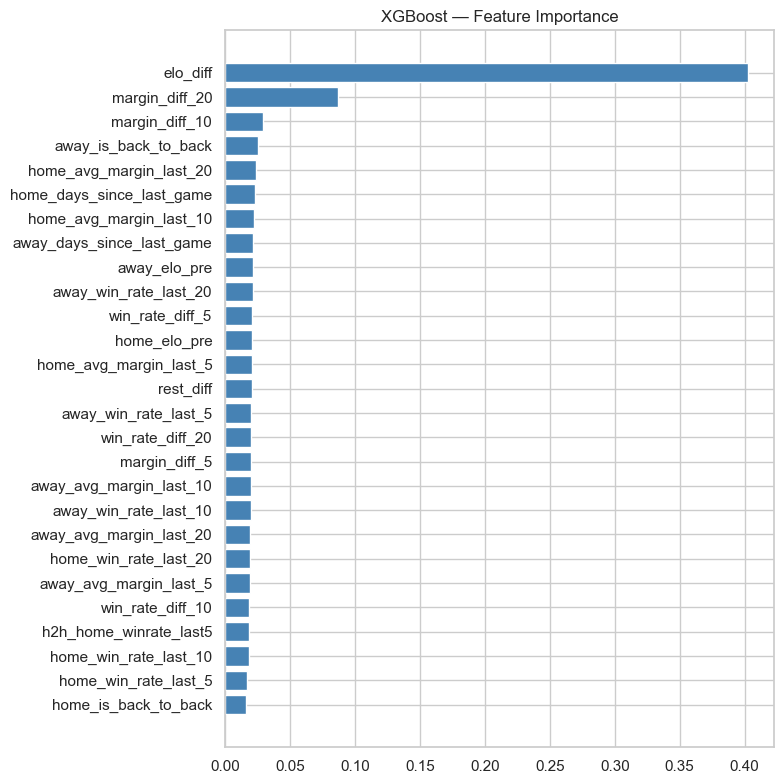

In [9]:
# XGBoost Feature Importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(importance.feature, importance.importance, color='steelblue')
ax.set_title('XGBoost — Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Vergleich aller Modelle

**Metriken im Ueberblick:**
- **Accuracy** — Anteil korrekter Vorhersagen (0=schlecht, 1=perfekt)
- **Log-Loss** — bestraft falsche, *selbstsichere* Vorhersagen stark (niedriger = besser)
- **Brier-Score** — mittlerer quadratischer Fehler der Wahrscheinlichkeiten (niedriger = besser)
- **AUC** — wie gut trennt das Modell Sieger von Verlierern (0.5=Zufall, 1=perfekt)

In [10]:
results_df = pd.DataFrame(results).T.round(4)
results_df

,accuracy,log_loss,brier,auc
Trivial (immer Heim),0.5523,0.6991,0.2528,0.5000
Logistische Regression,0.6429,0.6399,0.2230,0.6992
XGBoost,0.6416,0.6412,0.2239,0.6978


## 9. Kalibrierung — sind die Wahrscheinlichkeiten ehrlich?

Wenn das Modell sagt "70% Heimsieg", sollten in 70% dieser Faelle wirklich Heimsiege passieren. Eine perfekt kalibrierte Kurve liegt auf der Diagonalen. Das ist wichtig, wenn man die Wahrscheinlichkeiten weiterverwenden will (z.B. fuer Wett-Simulationen).

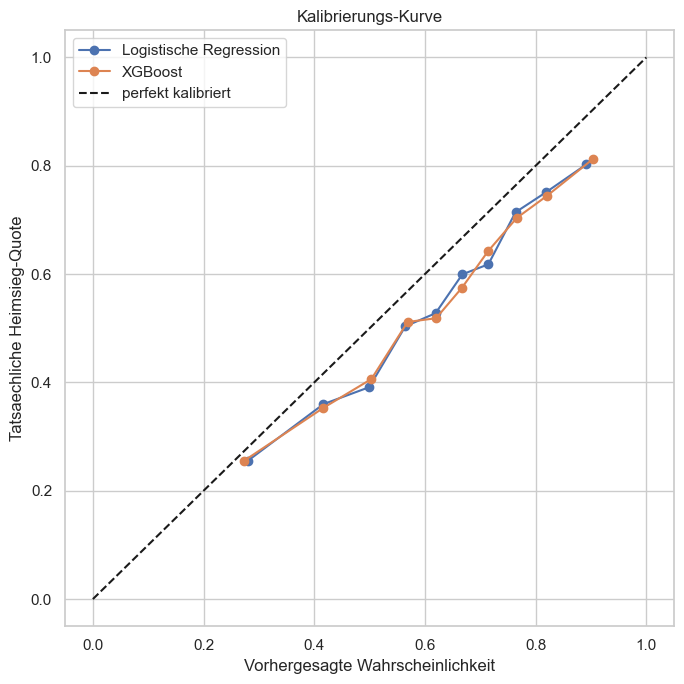

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))
for name, proba in [('Logistische Regression', lr_proba), ('XGBoost', xgb_proba)]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)

ax.plot([0, 1], [0, 1], 'k--', label='perfekt kalibriert')
ax.set_xlabel('Vorhergesagte Wahrscheinlichkeit')
ax.set_ylabel('Tatsaechliche Heimsieg-Quote')
ax.set_title('Kalibrierungs-Kurve')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Confusion Matrix (XGBoost)

Wo macht das Modell welche Fehler?

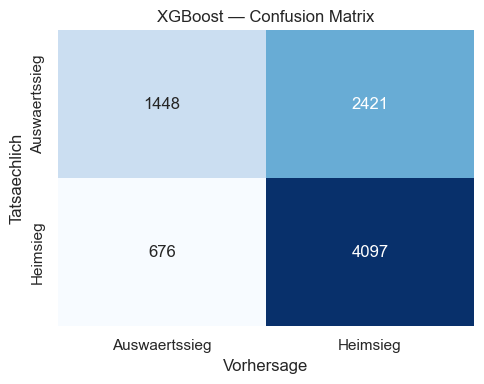

               precision    recall  f1-score   support

Auswaertssieg       0.68      0.37      0.48      3869
     Heimsieg       0.63      0.86      0.73      4773

     accuracy                           0.64      8642
    macro avg       0.66      0.62      0.60      8642
 weighted avg       0.65      0.64      0.62      8642



In [12]:
cm = confusion_matrix(y_test, xgb_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Auswaertssieg', 'Heimsieg'],
            yticklabels=['Auswaertssieg', 'Heimsieg'], ax=ax)
ax.set_xlabel('Vorhersage')
ax.set_ylabel('Tatsaechlich')
ax.set_title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, xgb_pred, target_names=['Auswaertssieg', 'Heimsieg']))

## 11. Modell speichern

Damit das naechste Notebook (Backtesting) das Modell laden kann.

In [13]:
import joblib
models_dir = Path('..') / 'models'
models_dir.mkdir(exist_ok=True)
joblib.dump(xgb_model, models_dir / 'xgb_baseline.pkl')
joblib.dump(logreg, models_dir / 'logreg_baseline.pkl')
print('Modelle gespeichert in models/')

Modelle gespeichert in models/


## 12. Naechste Schritte

**Was wir jetzt haben:** Ein Modell, das mit ~65% Accuracy NBA-Heimsiege vorhersagt — basierend nur auf Team-Form, ELO und Pause. Das ist im Bereich der publizierten Sport-Modelle.

**Verbesserungs-Ideen (spaeter):**
- Spieler-Features (Star-Verfuegbarkeit, Rotation-Tiefe) aus `PlayerStatistics.csv`
- Reise-Distanz / Heimat-Zeitzone
- Saison-Phase (Anfang vs. Ende)
- Hyperparameter-Tuning (Optuna o.ae.)

**Naechstes Notebook:** `04_backtesting.ipynb` — Walk-Forward-Validation: Modell jedes Jahr neu trainieren und auf der naechsten Saison testen, ueber 1947–heute.
